# Part A — Exploratory Data Analysis

1. Load Dataset and Display Basic Information

In [1]:
#Importing the Required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Load the dataset and with 5 heads of the dataset

df = pd.read_csv('/content/disease_risk_dataset -.csv')
df.head()

,age,sex,bmi,blood_pressure,cholesterol,blood_sugar,max_heart_rate,exercise_angina,smoking,family_history,disease_risk
0,58,0,29.9,107,239.0,87.0,155,1,1,1,1
1,71,0,29.3,134,235.0,119.0,185,1,1,0,1
2,48,0,22.5,122,262.0,53.0,143,0,1,0,0
3,34,1,26.0,140,200.0,104.0,156,0,0,0,0
4,62,0,15.5,132,215.0,NaN,137,1,1,1,0


In [4]:
#Check Datashape \

df.shape

(400, 11)

In [5]:
#Check Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              400 non-null    int64  
 1   sex              400 non-null    int64  
 2   bmi              392 non-null    float64
 3   blood_pressure   400 non-null    int64  
 4   cholesterol      392 non-null    float64
 5   blood_sugar      392 non-null    float64
 6   max_heart_rate   400 non-null    int64  
 7   exercise_angina  400 non-null    int64  
 8   smoking          400 non-null    int64  
 9   family_history   400 non-null    int64  
 10  disease_risk     400 non-null    int64  
dtypes: float64(3), int64(8)
memory usage: 34.5 KB


In [6]:
#Check data type

print("\nData Types:")
print(df.dtypes)


Data Types:
age                  int64
sex                  int64
bmi                float64
blood_pressure       int64
cholesterol        float64
blood_sugar        float64
max_heart_rate       int64
exercise_angina      int64
smoking              int64
family_history       int64
disease_risk         int64
dtype: object


In [7]:
#Check Descriptive Statistics

df.describe()

,age,sex,bmi,blood_pressure,cholesterol,blood_sugar,max_heart_rate,exercise_angina,smoking,family_history,disease_risk
count,400.000000,400.000000,392.000000,400.000000,392.000000,392.000000,400.000000,400.000000,400.00000,400.00000,400.000000
mean,49.882500,0.510000,26.003827,125.097500,209.086735,99.267857,149.365000,0.495000,0.49250,0.50750,0.450000
std,17.698072,0.500526,5.127022,17.393514,40.196227,24.924073,19.611177,0.500601,0.50057,0.50057,0.498117
min,20.000000,0.000000,15.000000,62.000000,94.000000,28.000000,81.000000,0.000000,0.00000,0.00000,0.000000
25%,35.000000,0.000000,22.700000,113.000000,180.750000,82.750000,136.000000,0.000000,0.00000,0.00000,0.000000
50%,51.000000,1.000000,26.000000,126.000000,210.500000,100.000000,150.000000,0.000000,0.00000,1.00000,0.000000
75%,64.250000,1.000000,29.700000,136.000000,237.000000,116.000000,163.000000,1.000000,1.00000,1.00000,1.000000
max,79.000000,1.000000,39.900000,178.000000,309.000000,168.000000,204.000000,1.000000,1.00000,1.00000,1.000000


2. Check Missing Values

In [8]:
#Missing values

df.isnull().sum()

,0
age,0
sex,0
bmi,8
blood_pressure,0
cholesterol,8
blood_sugar,8
max_heart_rate,0
exercise_angina,0
smoking,0
family_history,0


In [9]:
#Show only columns with missing values

df.columns[df.isnull().any()]

Index(['bmi', 'cholesterol', 'blood_sugar'], dtype='object')

In [10]:
#Missing values percentage calculation

missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\nMissing Values Percentage:")
print(missing_percentage)


Missing Values Percentage:
age                0.0
sex                0.0
bmi                2.0
blood_pressure     0.0
cholesterol        2.0
blood_sugar        2.0
max_heart_rate     0.0
exercise_angina    0.0
smoking            0.0
family_history     0.0
disease_risk       0.0
dtype: float64


3. Plot Class Distribution of disease_risk

In [11]:
# Class distribution
print("Disease Risk Class Counts:")
print(df["disease_risk"].value_counts())

print("\nDisease Risk Class Percentages:")
print(df["disease_risk"].value_counts(normalize=True) * 100)

Disease Risk Class Counts:
disease_risk
0    220
1    180
Name: count, dtype: int64

Disease Risk Class Percentages:
disease_risk
0    55.0
1    45.0
Name: proportion, dtype: float64


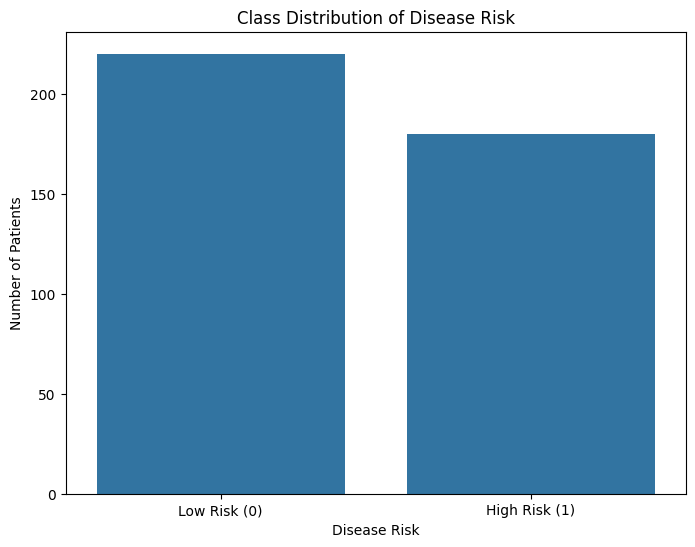

In [12]:
#Visualization of the class distribution

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x="disease_risk")
plt.title("Class Distribution of Disease Risk")
plt.xlabel("Disease Risk")
plt.ylabel("Number of Patients")
plt.xticks(
    ticks=[0, 1],
    labels=["Low Risk (0)", "High Risk (1)"]
)
plt.show()

4. Visualization 1 — Age vs Disease Risk

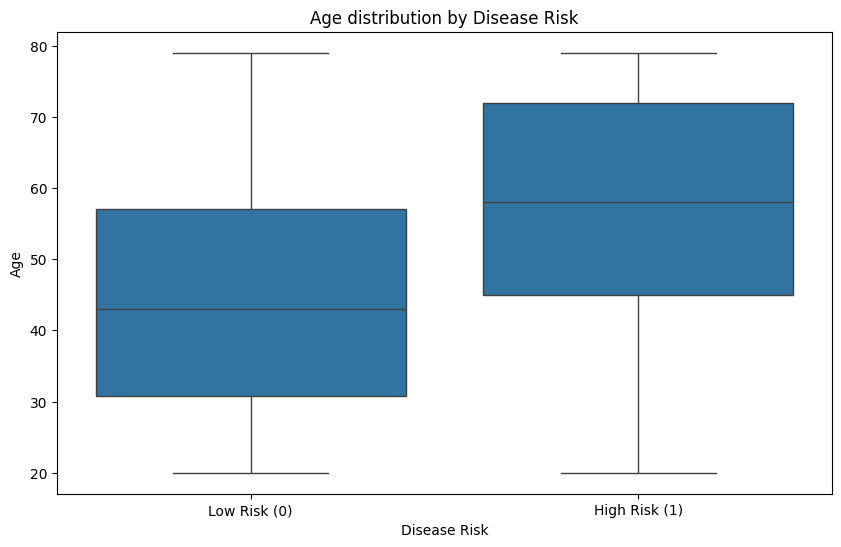

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="disease_risk", y="age")
plt.title("Age distribution by Disease Risk")
plt.xlabel("Disease Risk")
plt.ylabel("Age")
plt.xticks(
    ticks=[0, 1],
    labels=["Low Risk (0)", "High Risk (1)"]
)
plt.show()

5. Visualization 2 — Correlation Heatmap

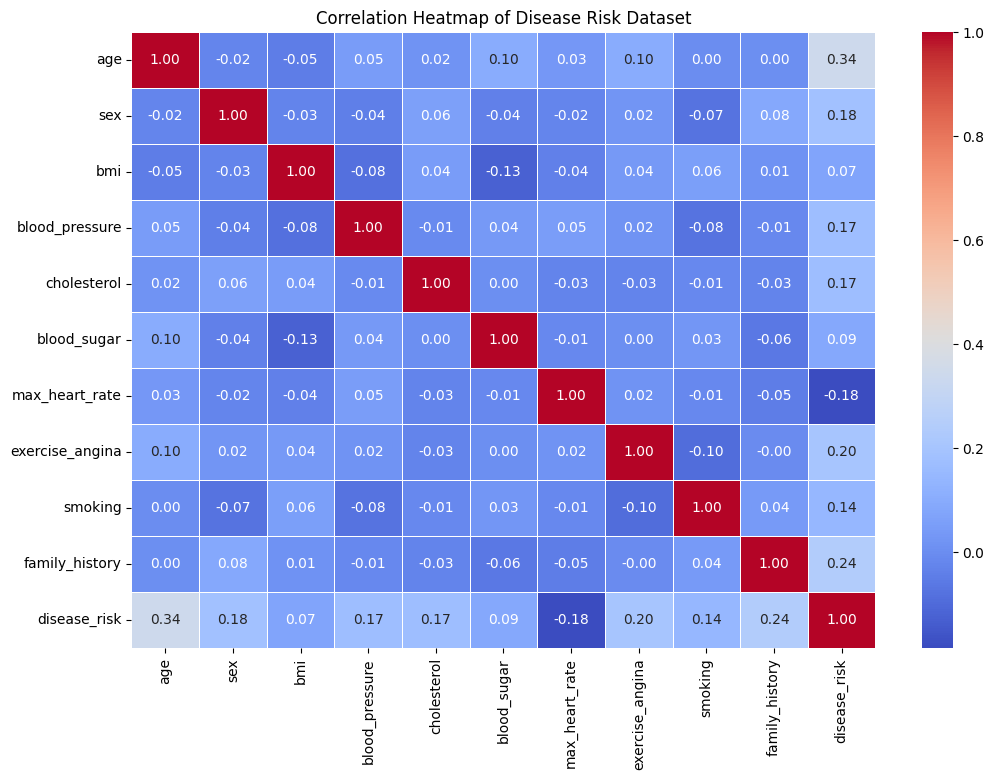

In [14]:
# Calculate correlation matrix

correlation_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Disease Risk Dataset")

plt.show()

In [15]:
#We can specifically focus on the correlation with Target

target_correlation = (
    df.corr()["disease_risk"]
    .sort_values(ascending=False)
    .drop("disease_risk")
)

print("Correlation with Disease Risk:")
display(target_correlation)

Correlation with Disease Risk:


,disease_risk
age,0.342903
family_history,0.237718
exercise_angina,0.200013
sex,0.182953
cholesterol,0.169198
blood_pressure,0.168487
smoking,0.144239
blood_sugar,0.087451
bmi,0.074892
max_heart_rate,-0.183878


6. Visualization 3 — BMI vs Disease Risk

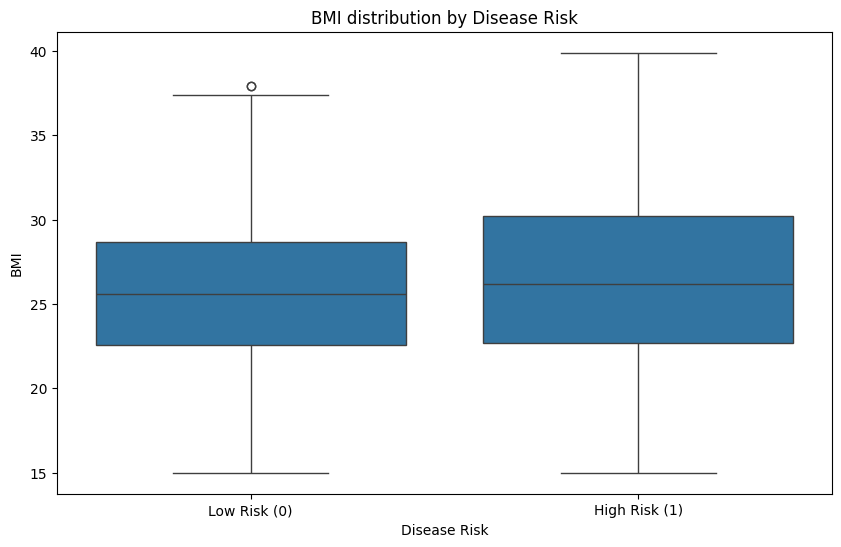

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="disease_risk", y="bmi")
plt.title("BMI distribution by Disease Risk")
plt.xlabel("Disease Risk")
plt.ylabel("BMI")
plt.xticks(
    ticks=[0, 1],
    labels=["Low Risk (0)", "High Risk (1)"]
)
plt.show()

7. Visualization 4 — Blood Pressure vs Disease Risk

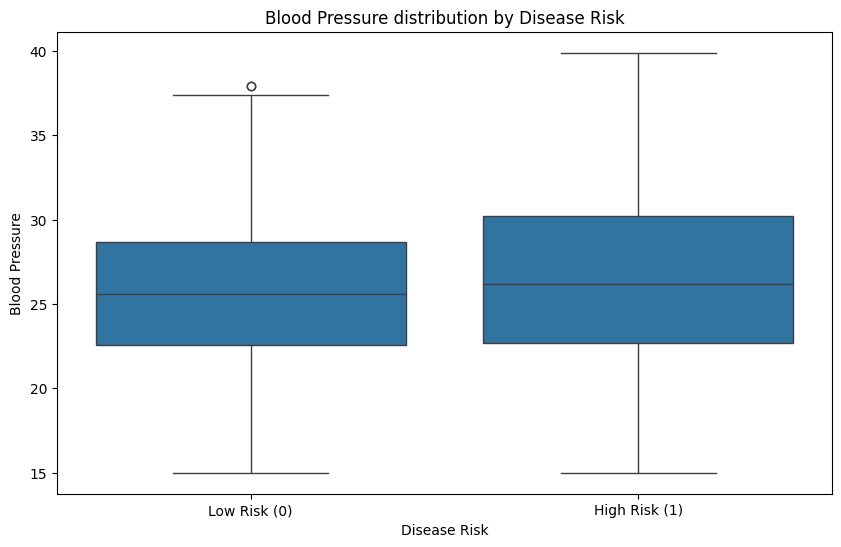

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="disease_risk", y="bmi")
plt.title("Blood Pressure distribution by Disease Risk")
plt.xlabel("Disease Risk")
plt.ylabel("Blood Pressure")
plt.xticks(
    ticks=[0, 1],
    labels=["Low Risk (0)", "High Risk (1)"]
)
plt.show()

# Part B — Preprocessing


#1. From Part A, we found missing values in:

bmi → 8 missing

cholesterol → 8 missing

blood_sugar → 8 missing

In [18]:
#Missing Value Handling with Median imputation

from sklearn.impute import SimpleImputer

# Columns with missing values
missing_cols = ["bmi", "cholesterol", "blood_sugar"]

# Check missing values before imputation
print("Missing values before imputation:")
print(df[missing_cols].isnull().sum())



Missing values before imputation:
bmi            8
cholesterol    8
blood_sugar    8
dtype: int64


In [19]:
imputer = SimpleImputer(strategy="median")

# 2. Split Data into Features (X) and Target (y)

In [20]:
# Define features and target

X = df.drop("disease_risk", axis=1)
y = df["disease_risk"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Features (X) shape: (400, 10)
Target (y) shape: (400,)

Feature columns:
['age', 'sex', 'bmi', 'blood_pressure', 'cholesterol', 'blood_sugar', 'max_heart_rate', 'exercise_angina', 'smoking', 'family_history']

Target distribution:
disease_risk
0    220
1    180
Name: count, dtype: int64


# 3.Train/Test Split — 80/20

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (320, 10)
y_train: (320,)

Testing set:
X_test: (80, 10)
y_test: (80,)


# 4. Check Class Distribution



In [22]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
disease_risk
0    0.55
1    0.45
Name: proportion, dtype: float64

Testing target distribution:
disease_risk
0    0.55
1    0.45
Name: proportion, dtype: float64


# 5.Scaling Numerical Features

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [24]:
#Features and Target

# Target
y = df["disease_risk"]

# Features
X = df.drop("disease_risk", axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())


X shape: (400, 10)
y shape: (400,)

Feature columns:
['age', 'sex', 'bmi', 'blood_pressure', 'cholesterol', 'blood_sugar', 'max_heart_rate', 'exercise_angina', 'smoking', 'family_history']


In [25]:
#Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining set shape:")
print(X_train.shape)

print("\nTesting set shape:")
print(X_test.shape)



Training set shape:
(320, 10)

Testing set shape:
(80, 10)


In [26]:
#Identify numerical features

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
print("Numerical features:", numerical_features)

Numerical features: ['age', 'sex', 'bmi', 'blood_pressure', 'cholesterol', 'blood_sugar', 'max_heart_rate', 'exercise_angina', 'smoking', 'family_history']


In [27]:
#Preprocessing for Scale sensitive Models

scaled_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [28]:
# Fit ONLY on training data

X_train_scaled = scaled_preprocessor.fit_transform(X_train)

In [29]:
# Transform test data using training parameters

X_test_scaled = scaled_preprocessor.transform(X_test)


In [30]:
print("\nScaled Training Data Shape:")
print(X_train_scaled.shape)

print("\nScaled Testing Data Shape:")
print(X_test_scaled.shape)


Scaled Training Data Shape:
(320, 10)

Scaled Testing Data Shape:
(80, 10)


# Preprocessing for Treed Based Models

In [32]:
tree_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])


# Fit only on training data
X_train_tree = tree_preprocessor.fit_transform(X_train)

# Transform test data
X_test_tree = tree_preprocessor.transform(X_test)


print("\nTree-based Training Data Shape:")
print(X_train_tree.shape)

print("\nTree-based Testing Data Shape:")
print(X_test_tree.shape)


Tree-based Training Data Shape:
(320, 10)

Tree-based Testing Data Shape:
(80, 10)


In [33]:
#Varifying missing values are handled for Scaled Data

print("Missing values after preprocessing:")

print("X_train_scaled:", np.isnan(X_train_scaled).sum())
print("X_test_scaled:", np.isnan(X_test_scaled).sum())

Missing values after preprocessing:
X_train_scaled: 0
X_test_scaled: 0


In [34]:
#Varifying missing values are handled for Tree Based Processing

print("Missing values in tree-based data:")

print("X_train_tree:", np.isnan(X_train_tree).sum())
print("X_test_tree:", np.isnan(X_test_tree).sum())

Missing values in tree-based data:
X_train_tree: 0
X_test_tree: 0


# Part C — Model Training

In [35]:
#Required Libraries

import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import GridSearchCV

#We can use Pipeline again

In [36]:
scaled_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [37]:
tree_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Evaluation Function

In [38]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Probabilities / decision scores for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_test_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_test_prob = model.decision_function(X_test)

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print("\nTraining Accuracy:")
    print(round(accuracy_score(y_train, y_train_pred), 4))

    print("\nTest Accuracy:")
    print(round(accuracy_score(y_test, y_test_pred), 4))

    print("\nPrecision:")
    print(round(precision_score(y_test, y_test_pred), 4))

    print("\nRecall:")
    print(round(recall_score(y_test, y_test_pred), 4))

    print("\nF1 Score:")
    print(round(f1_score(y_test, y_test_pred), 4))

    print("\nROC-AUC:")
    print(round(roc_auc_score(y_test, y_test_prob), 4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_test_pred))

    return model

In [39]:
#Logistic Regression

logistic_default = Pipeline([
    ("preprocessing", scaled_preprocessor),
    ("model", LogisticRegression())
])

In [40]:
#Train and Evaluate

logistic_default = evaluate_model(
    logistic_default,
    X_train,
    X_test,
    y_train,
    y_test,
    "Logistic Regression - Default"
)

Logistic Regression - Default

Training Accuracy:
0.7906

Test Accuracy:
0.7625

Precision:
0.7297

Recall:
0.75

F1 Score:
0.7397

ROC-AUC:
0.7904

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.77      0.78        44
           1       0.73      0.75      0.74        36

    accuracy                           0.76        80
   macro avg       0.76      0.76      0.76        80
weighted avg       0.76      0.76      0.76        80


Confusion Matrix:
[[34 10]
 [ 9 27]]


In [41]:
#Logistic Regression — Hyperparameter Tuning

logistic_pipeline = Pipeline([
    ("preprocessing", scaled_preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

logistic_grid = GridSearchCV(
    logistic_pipeline,
    logistic_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

logistic_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        Pipeline(steps=[('imputer',
                                                         SimpleImputer(strategy='median')),
                                                        ('scaler',
                                                         StandardScaler())])),
                                       ('model',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1, param_grid={'model__C': [0.01, 0.1, 1, 10, 100]},
             scoring='accuracy')

In [42]:
#Best Parameters

print("Best Logistic Regression Parameters:")
print(logistic_grid.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(logistic_grid.best_score_)

Best Logistic Regression Parameters:
{'model__C': 0.1}

Best Cross-Validation Accuracy:
0.753125


In [43]:
#Evaluate Trained Model

logistic_tuned = logistic_grid.best_estimator_

evaluate_model(
    logistic_tuned,
    X_train,
    X_test,
    y_train,
    y_test,
    "Logistic Regression - Tuned"
)

Logistic Regression - Tuned

Training Accuracy:
0.7906

Test Accuracy:
0.75

Precision:
0.7222

Recall:
0.7222

F1 Score:
0.7222

ROC-AUC:
0.7872

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.77      0.77        44
           1       0.72      0.72      0.72        36

    accuracy                           0.75        80
   macro avg       0.75      0.75      0.75        80
weighted avg       0.75      0.75      0.75        80


Confusion Matrix:
[[34 10]
 [10 26]]


Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model', LogisticRegression(C=0.1, max_iter=1000))])

In [44]:
#SVM — Linear Kernel

svm_linear_default = Pipeline([
    ("preprocessing", scaled_preprocessor),
    ("model", SVC(kernel="linear"))
])

In [45]:
svm_linear_default = evaluate_model(
    svm_linear_default,
    X_train,
    X_test,
    y_train,
    y_test,
    "SVM - Linear Kernel - Default"
)

SVM - Linear Kernel - Default

Training Accuracy:
0.7969

Test Accuracy:
0.7

Precision:
0.6579

Recall:
0.6944

F1 Score:
0.6757

ROC-AUC:
0.7841

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.70      0.72        44
           1       0.66      0.69      0.68        36

    accuracy                           0.70        80
   macro avg       0.70      0.70      0.70        80
weighted avg       0.70      0.70      0.70        80


Confusion Matrix:
[[31 13]
 [11 25]]


In [46]:
#SVM Linear — Hyperparameter Tuning

svm_linear_pipeline = Pipeline([
    ("preprocessing", scaled_preprocessor),
    ("model", SVC(kernel="linear"))
])

svm_linear_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

svm_linear_grid = GridSearchCV(
    svm_linear_pipeline,
    svm_linear_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

svm_linear_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        Pipeline(steps=[('imputer',
                                                         SimpleImputer(strategy='median')),
                                                        ('scaler',
                                                         StandardScaler())])),
                                       ('model', SVC(kernel='linear'))]),
             n_jobs=-1, param_grid={'model__C': [0.01, 0.1, 1, 10, 100]},
             scoring='accuracy')

In [47]:
print("Best Linear SVM Parameters:")
print(svm_linear_grid.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(svm_linear_grid.best_score_)

Best Linear SVM Parameters:
{'model__C': 0.01}

Best Cross-Validation Accuracy:
0.7625


In [48]:
#Evaluation

svm_linear_tuned = svm_linear_grid.best_estimator_

evaluate_model(
    svm_linear_tuned,
    X_train,
    X_test,
    y_train,
    y_test,
    "SVM - Linear Kernel - Tuned"
)

SVM - Linear Kernel - Tuned

Training Accuracy:
0.7875

Test Accuracy:
0.675

Precision:
0.6471

Recall:
0.6111

F1 Score:
0.6286

ROC-AUC:
0.7652

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.73      0.71        44
           1       0.65      0.61      0.63        36

    accuracy                           0.68        80
   macro avg       0.67      0.67      0.67        80
weighted avg       0.67      0.68      0.67        80


Confusion Matrix:
[[32 12]
 [14 22]]


Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model', SVC(C=0.01, kernel='linear'))])

In [49]:
#SVM — RBF Kernel

svm_rbf_default = Pipeline([
    ("preprocessing", scaled_preprocessor),
    ("model", SVC(kernel="rbf"))
])

In [50]:
svm_rbf_default = evaluate_model(
    svm_rbf_default,
    X_train,
    X_test,
    y_train,
    y_test,
    "SVM - RBF Kernel - Default"
)

SVM - RBF Kernel - Default

Training Accuracy:
0.8562

Test Accuracy:
0.6875

Precision:
0.6774

Recall:
0.5833

F1 Score:
0.6269

ROC-AUC:
0.7727

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.77      0.73        44
           1       0.68      0.58      0.63        36

    accuracy                           0.69        80
   macro avg       0.69      0.68      0.68        80
weighted avg       0.69      0.69      0.68        80


Confusion Matrix:
[[34 10]
 [15 21]]


In [51]:
#SVM RBF — Hyperparameter Tuning

svm_rbf_pipeline = Pipeline([
    ("preprocessing", scaled_preprocessor),
    ("model", SVC(kernel="rbf"))
])

svm_rbf_param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", 0.01, 0.1, 1]
}

svm_rbf_grid = GridSearchCV(
    svm_rbf_pipeline,
    svm_rbf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

svm_rbf_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        Pipeline(steps=[('imputer',
                                                         SimpleImputer(strategy='median')),
                                                        ('scaler',
                                                         StandardScaler())])),
                                       ('model', SVC())]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10, 100],
                         'model__gamma': ['scale', 0.01, 0.1, 1]},
             scoring='accuracy')

In [52]:
print("Best RBF SVM Parameters:")
print(svm_rbf_grid.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(svm_rbf_grid.best_score_)

Best RBF SVM Parameters:
{'model__C': 1, 'model__gamma': 0.01}

Best Cross-Validation Accuracy:
0.75


In [53]:
#Evaluate
svm_rbf_tuned = svm_rbf_grid.best_estimator_

evaluate_model(
    svm_rbf_tuned,
    X_train,
    X_test,
    y_train,
    y_test,
    "SVM - RBF Kernel - Tuned"
)

SVM - RBF Kernel - Tuned

Training Accuracy:
0.7906

Test Accuracy:
0.6375

Precision:
0.6061

Recall:
0.5556

F1 Score:
0.5797

ROC-AUC:
0.7702

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.70      0.68        44
           1       0.61      0.56      0.58        36

    accuracy                           0.64        80
   macro avg       0.63      0.63      0.63        80
weighted avg       0.64      0.64      0.64        80


Confusion Matrix:
[[31 13]
 [16 20]]


Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model', SVC(C=1, gamma=0.01))])

In [54]:
#Gaussian Naive Bayes

nb_default = Pipeline([
    ("preprocessing", tree_preprocessor),
    ("model", GaussianNB())
])

In [55]:
nb_default = evaluate_model(
    nb_default,
    X_train,
    X_test,
    y_train,
    y_test,
    "Gaussian Naive Bayes - Default"
)

Gaussian Naive Bayes - Default

Training Accuracy:
0.7906

Test Accuracy:
0.7

Precision:
0.6579

Recall:
0.6944

F1 Score:
0.6757

ROC-AUC:
0.767

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.70      0.72        44
           1       0.66      0.69      0.68        36

    accuracy                           0.70        80
   macro avg       0.70      0.70      0.70        80
weighted avg       0.70      0.70      0.70        80


Confusion Matrix:
[[31 13]
 [11 25]]


In [56]:
#Gaussian Naive Bayes — Hyperparameter Tuning

nb_pipeline = Pipeline([
    ("preprocessing", scaled_preprocessor),
    ("model", GaussianNB())
])

nb_param_grid = {
    "model__var_smoothing": [
        1e-11,
        1e-10,
        1e-9,
        1e-8,
        1e-7
    ]
}

nb_grid = GridSearchCV(
    nb_pipeline,
    nb_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

nb_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        Pipeline(steps=[('imputer',
                                                         SimpleImputer(strategy='median')),
                                                        ('scaler',
                                                         StandardScaler())])),
                                       ('model', GaussianNB())]),
             n_jobs=-1,
             param_grid={'model__var_smoothing': [1e-11, 1e-10, 1e-09, 1e-08,
                                                  1e-07]},
             scoring='accuracy')

In [57]:
#Check best parameter

print("Best GaussianNB Parameters:")
print(nb_grid.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(nb_grid.best_score_)

Best GaussianNB Parameters:
{'model__var_smoothing': 1e-11}

Best Cross-Validation Accuracy:
0.75625


In [58]:
#Evaluation

nb_tuned = nb_grid.best_estimator_

evaluate_model(
    nb_tuned,
    X_train,
    X_test,
    y_train,
    y_test,
    "Gaussian Naive Bayes - Tuned"
)

Gaussian Naive Bayes - Tuned

Training Accuracy:
0.7906

Test Accuracy:
0.7

Precision:
0.6579

Recall:
0.6944

F1 Score:
0.6757

ROC-AUC:
0.767

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.70      0.72        44
           1       0.66      0.69      0.68        36

    accuracy                           0.70        80
   macro avg       0.70      0.70      0.70        80
weighted avg       0.70      0.70      0.70        80


Confusion Matrix:
[[31 13]
 [11 25]]


Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model', GaussianNB(var_smoothing=1e-11))])

In [59]:
#Decision Tree

dt_default = Pipeline([
    ("preprocessing", tree_preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

In [60]:
dt_default = evaluate_model(
    dt_default,
    X_train,
    X_test,
    y_train,
    y_test,
    "Decision Tree - Default"
)

Decision Tree - Default

Training Accuracy:
1.0

Test Accuracy:
0.5375

Precision:
0.4848

Recall:
0.4444

F1 Score:
0.4638

ROC-AUC:
0.529

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.61      0.59        44
           1       0.48      0.44      0.46        36

    accuracy                           0.54        80
   macro avg       0.53      0.53      0.53        80
weighted avg       0.53      0.54      0.54        80


Confusion Matrix:
[[27 17]
 [20 16]]


In [61]:
#Decision Tree — Hyperparameter Tuning

dt_pipeline = Pipeline([
    ("preprocessing", tree_preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_param_grid = {
    "model__max_depth": [2, 3, 4, 5, 6, 8, 10]
}

dt_grid = GridSearchCV(
    dt_pipeline,
    dt_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        Pipeline(steps=[('imputer',
                                                         SimpleImputer(strategy='median'))])),
                                       ('model',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1, param_grid={'model__max_depth': [2, 3, 4, 5, 6, 8, 10]},
             scoring='accuracy')

In [62]:
#Check best parameter

print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(dt_grid.best_score_)

Best Decision Tree Parameters:
{'model__max_depth': 4}

Best Cross-Validation Accuracy:
0.69375


In [63]:
#Evaluation

dt_tuned = dt_grid.best_estimator_

evaluate_model(
    dt_tuned,
    X_train,
    X_test,
    y_train,
    y_test,
    "Decision Tree - Tuned"
)

Decision Tree - Tuned

Training Accuracy:
0.8

Test Accuracy:
0.5125

Precision:
0.4595

Recall:
0.4722

F1 Score:
0.4658

ROC-AUC:
0.5202

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.55      0.55        44
           1       0.46      0.47      0.47        36

    accuracy                           0.51        80
   macro avg       0.51      0.51      0.51        80
weighted avg       0.51      0.51      0.51        80


Confusion Matrix:
[[24 20]
 [19 17]]


Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('imputer',
                                  SimpleImputer(strategy='median'))])),
                ('model',
                 DecisionTreeClassifier(max_depth=4, random_state=42))])

In [64]:
#Final Model Comparison Table

def get_model_results(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    return {
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred),
        "Recall": recall_score(y_test, y_test_pred),
        "F1 Score": f1_score(y_test, y_test_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [65]:
#Now collect all default and tuned models:

results = {}

# Default models
results["Logistic Regression - Default"] = get_model_results(
    logistic_default, X_train, X_test, y_train, y_test
)

results["SVM Linear - Default"] = get_model_results(
    svm_linear_default, X_train, X_test, y_train, y_test
)

results["SVM RBF - Default"] = get_model_results(
    svm_rbf_default, X_train, X_test, y_train, y_test
)

results["GaussianNB - Default"] = get_model_results(
    nb_default, X_train, X_test, y_train, y_test
)

results["Decision Tree - Default"] = get_model_results(
    dt_default, X_train, X_test, y_train, y_test
)


# Tuned models
results["Logistic Regression - Tuned"] = get_model_results(
    logistic_tuned, X_train, X_test, y_train, y_test
)

results["SVM Linear - Tuned"] = get_model_results(
    svm_linear_tuned, X_train, X_test, y_train, y_test
)

results["SVM RBF - Tuned"] = get_model_results(
    svm_rbf_tuned, X_train, X_test, y_train, y_test
)

results["GaussianNB - Tuned"] = get_model_results(
    nb_tuned, X_train, X_test, y_train, y_test
)

results["Decision Tree - Tuned"] = get_model_results(
    dt_tuned, X_train, X_test, y_train, y_test
)

In [66]:
#Convert to DataFrame

results_df = pd.DataFrame(results).T

results_df = results_df.round(4)

display(results_df)

,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression - Default,0.7906,0.7625,0.7297,0.7500,0.7397,0.7904
SVM Linear - Default,0.7969,0.7000,0.6579,0.6944,0.6757,0.7841
SVM RBF - Default,0.8562,0.6875,0.6774,0.5833,0.6269,0.7727
GaussianNB - Default,0.7906,0.7000,0.6579,0.6944,0.6757,0.7670
Decision Tree - Default,1.0000,0.5375,0.4848,0.4444,0.4638,0.5290
Logistic Regression - Tuned,0.7906,0.7500,0.7222,0.7222,0.7222,0.7872
SVM Linear - Tuned,0.7875,0.6750,0.6471,0.6111,0.6286,0.7652
SVM RBF - Tuned,0.7906,0.6375,0.6061,0.5556,0.5797,0.7702
GaussianNB - Tuned,0.7906,0.7000,0.6579,0.6944,0.6757,0.7670
Decision Tree - Tuned,0.8000,0.5125,0.4595,0.4722,0.4658,0.5202


What we Should Explain in the Report :

Logistic Regression provides a linear decision boundary. The C parameter was tuned because it controls the strength of regularization. Feature scaling was applied because Logistic Regression is sensitive to feature magnitude, particularly when regularization is used.

SVM

Two kernels were tested:

Linear kernel — produces a linear decision boundary.
RBF kernel — can model nonlinear relationships.

For the Linear SVM, C was tuned. For the RBF SVM, both C and gamma were tuned.

Gaussian Naive Bayes

GaussianNB assumes that each numerical feature follows a Gaussian distribution within each class and that features are conditionally independent given the class. The var_smoothing parameter was tuned to control numerical variance smoothing.

Decision Tree

The Decision Tree creates a sequence of feature-based splits. max_depth was tuned to control tree complexity and help reduce overfitting. Scaling was not required because Decision Trees are based on threshold splits rather than distances.

One Important Improvement

For my final model selection, i should not rely only on accuracy. Since this is a disease-risk classification problem, we should also examine:

Recall — particularly important if missing a high-risk patient is costly.
Precision
F1-score
ROC-AUC
Confusion matrix

That will be especially useful in Part D — Model Evaluation, where we can generate the confusion matrices, ROC curves, and a detailed comparison of all five model variants.

# Part D — Model Evaluation

In [67]:
# Define the Final Models

# Final tuned models from Part C

final_models = {
    "Logistic Regression": logistic_tuned,
    "SVM - Linear": svm_linear_tuned,
    "SVM - RBF": svm_rbf_tuned,
    "Naive Bayes": nb_tuned,
    "Decision Tree": dt_tuned
}

In [68]:
#Evaluate Accuracy, Precision, Recall and F1-Score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

def evaluate_model(model, X_test, y_test, model_name):

    # Prediction
    y_pred = model.predict(X_test)

    # Probability / decision score
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_score)

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

In [69]:
#Generate Classification Reports

results = []

for name, model in final_models.items():

    result = evaluate_model(
        model,
        X_test,
        y_test,
        name
    )

    results.append(result)

Logistic Regression
Accuracy : 0.7500
Precision: 0.7222
Recall   : 0.7222
F1-Score : 0.7222
ROC-AUC  : 0.7872

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.77      0.77        44
           1       0.72      0.72      0.72        36

    accuracy                           0.75        80
   macro avg       0.75      0.75      0.75        80
weighted avg       0.75      0.75      0.75        80

SVM - Linear
Accuracy : 0.6750
Precision: 0.6471
Recall   : 0.6111
F1-Score : 0.6286
ROC-AUC  : 0.7652

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.73      0.71        44
           1       0.65      0.61      0.63        36

    accuracy                           0.68        80
   macro avg       0.67      0.67      0.67        80
weighted avg       0.67      0.68      0.67        80

SVM - RBF
Accuracy : 0.6375
Precision: 0.6061
Recall   : 0.5556
F1-Score : 0.5797
ROC

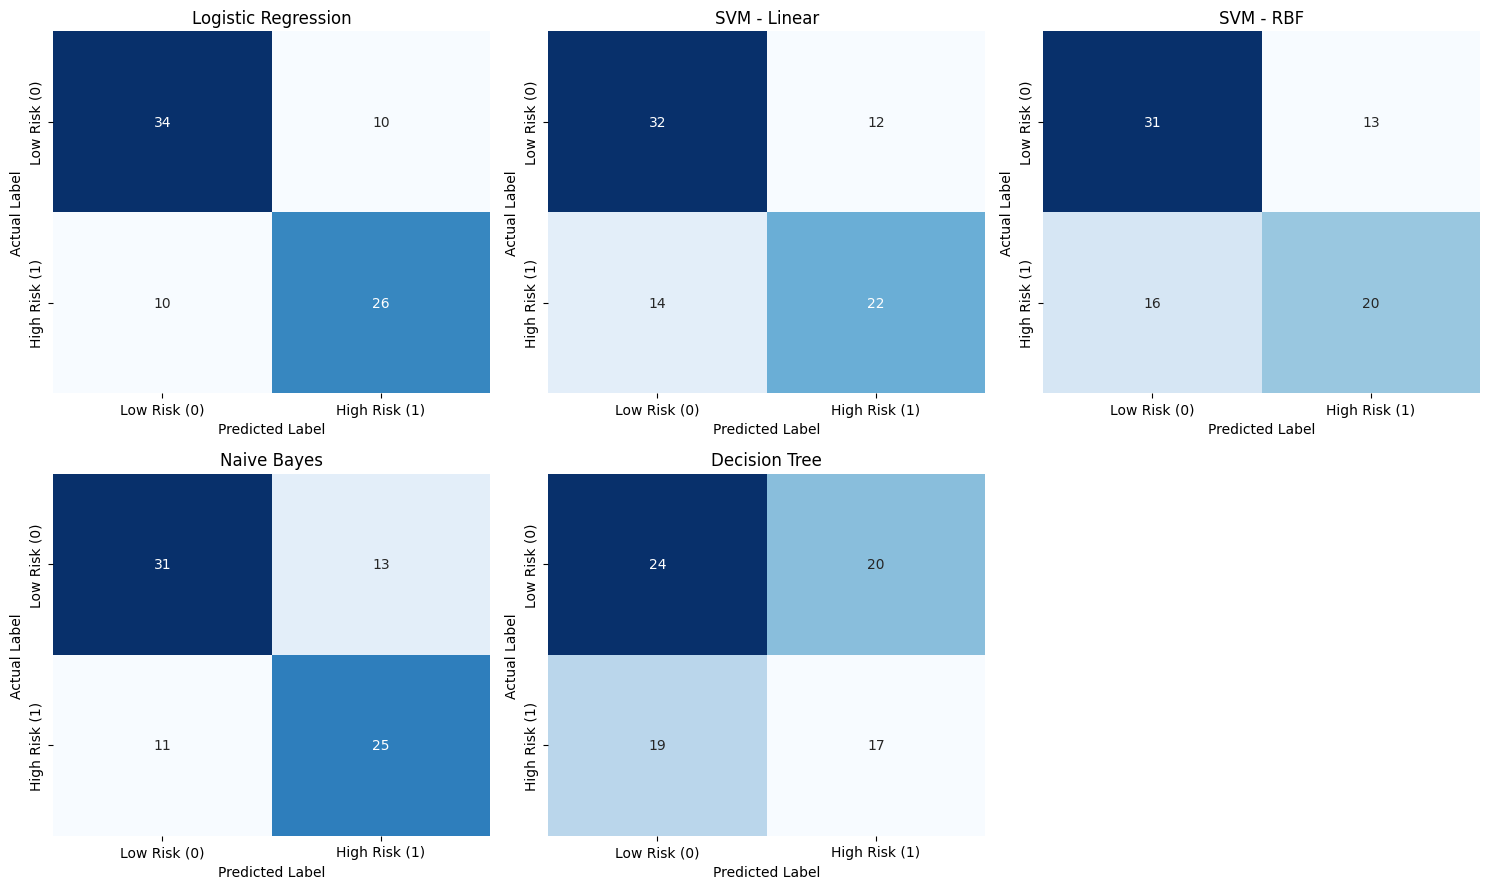

In [70]:
# CONFUSION MATRICES

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

axes = axes.ravel()

for i, (name, model) in enumerate(final_models.items()):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axes[i]
    )

    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("Actual Label")

    axes[i].set_xticklabels(["Low Risk (0)", "High Risk (1)"])
    axes[i].set_yticklabels(["Low Risk (0)", "High Risk (1)"])

# Hide unused subplot
if len(final_models) < len(axes):
    for j in range(len(final_models), len(axes)):
        axes[j].axis("off")

plt.tight_layout()
plt.show()

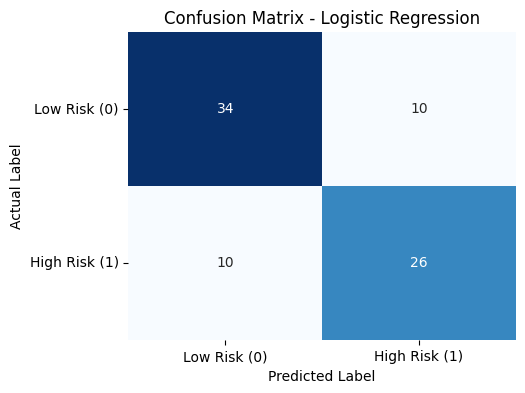

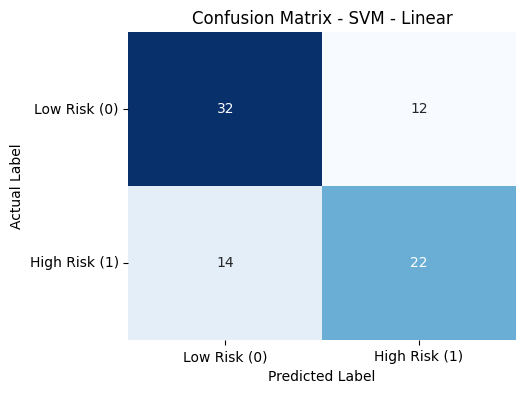

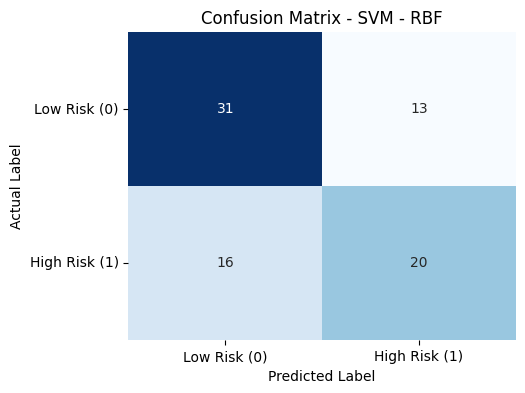

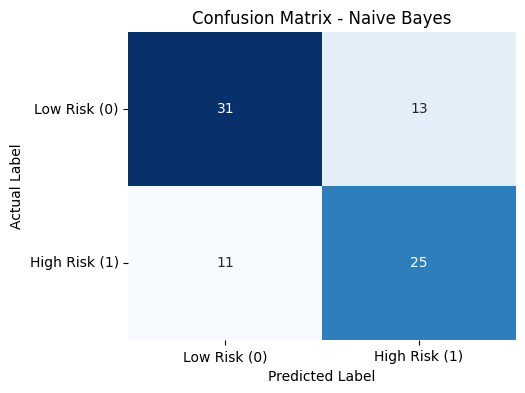

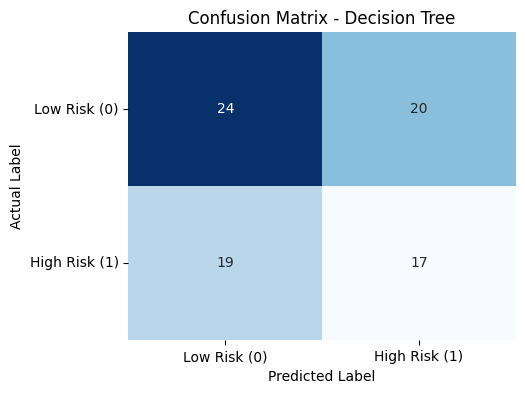

In [71]:
#Individual Confusion Matrix

for name, model in final_models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.xticks(
        [0.5, 1.5],
        ["Low Risk (0)", "High Risk (1)"]
    )

    plt.yticks(
        [0.5, 1.5],
        ["Low Risk (0)", "High Risk (1)"],
        rotation=0
    )

    plt.show()

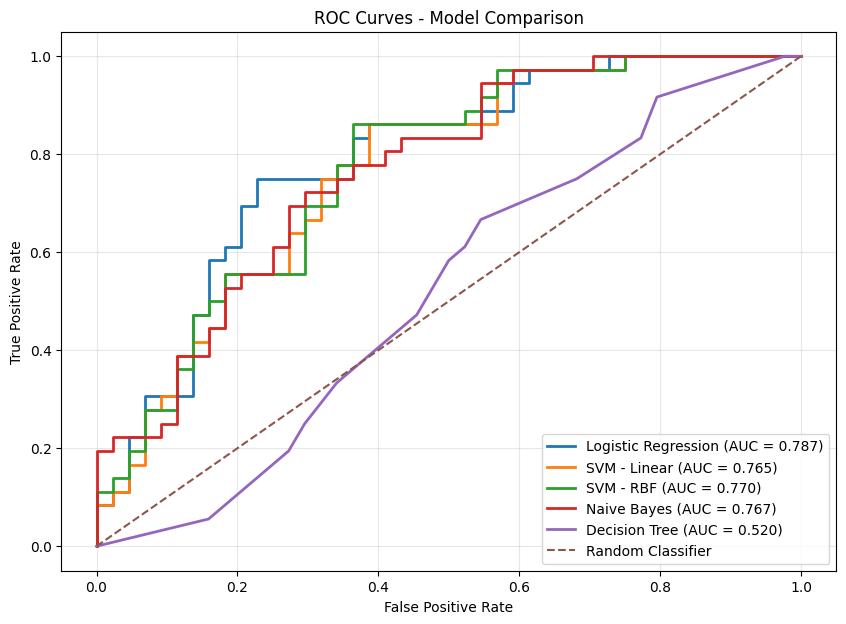

In [72]:
#ROC-AUC and ROC Curves

plt.figure(figsize=(10, 7))

for name, model in final_models.items():

    # Get prediction scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    # ROC curve
    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_score
    )

    # AUC
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Create the Required Summary Comparison Table

In [73]:
results_df = pd.DataFrame(results)

results_df = results_df.set_index("Model")

results_df = results_df.round(4)

display(results_df)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7500,0.7222,0.7222,0.7222,0.7872
SVM - Linear,0.6750,0.6471,0.6111,0.6286,0.7652
SVM - RBF,0.6375,0.6061,0.5556,0.5797,0.7702
Naive Bayes,0.7000,0.6579,0.6944,0.6757,0.7670
Decision Tree,0.5125,0.4595,0.4722,0.4658,0.5202


In [74]:
#Classification Report for Each Model

for name, model in final_models.items():

    y_pred = model.predict(X_test)

    print("\n" + "=" * 70)
    print(f"CLASSIFICATION REPORT - {name}")
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Low Risk (0)",
                "High Risk (1)"
            ]
        )
    )


CLASSIFICATION REPORT - Logistic Regression
               precision    recall  f1-score   support

 Low Risk (0)       0.77      0.77      0.77        44
High Risk (1)       0.72      0.72      0.72        36

     accuracy                           0.75        80
    macro avg       0.75      0.75      0.75        80
 weighted avg       0.75      0.75      0.75        80


CLASSIFICATION REPORT - SVM - Linear
               precision    recall  f1-score   support

 Low Risk (0)       0.70      0.73      0.71        44
High Risk (1)       0.65      0.61      0.63        36

     accuracy                           0.68        80
    macro avg       0.67      0.67      0.67        80
 weighted avg       0.67      0.68      0.67        80


CLASSIFICATION REPORT - SVM - RBF
               precision    recall  f1-score   support

 Low Risk (0)       0.66      0.70      0.68        44
High Risk (1)       0.61      0.56      0.58        36

     accuracy                           0.64     

# Complete Part D Code — One Cell

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

In [76]:
#Final Tuned Models

final_models = {
    "Logistic Regression": logistic_tuned,
    "SVM - Linear": svm_linear_tuned,
    "SVM - RBF": svm_rbf_tuned,
    "Naive Bayes": nb_tuned,
    "Decision Tree": dt_tuned
}


In [77]:
#Evaluation

results = []

for name, model in final_models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Scores for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_score)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

    # Classification report
    print("\n" + "=" * 70)
    print(f"CLASSIFICATION REPORT - {name}")
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Low Risk (0)",
                "High Risk (1)"
            ]
        )
    )




CLASSIFICATION REPORT - Logistic Regression
               precision    recall  f1-score   support

 Low Risk (0)       0.77      0.77      0.77        44
High Risk (1)       0.72      0.72      0.72        36

     accuracy                           0.75        80
    macro avg       0.75      0.75      0.75        80
 weighted avg       0.75      0.75      0.75        80


CLASSIFICATION REPORT - SVM - Linear
               precision    recall  f1-score   support

 Low Risk (0)       0.70      0.73      0.71        44
High Risk (1)       0.65      0.61      0.63        36

     accuracy                           0.68        80
    macro avg       0.67      0.67      0.67        80
 weighted avg       0.67      0.68      0.67        80


CLASSIFICATION REPORT - SVM - RBF
               precision    recall  f1-score   support

 Low Risk (0)       0.66      0.70      0.68        44
High Risk (1)       0.61      0.56      0.58        36

     accuracy                           0.64     

In [78]:
#Summary Table

results_df = pd.DataFrame(results)

results_df = results_df.set_index("Model")

results_df = results_df.round(4)

print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

display(results_df)


FINAL MODEL COMPARISON


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7500,0.7222,0.7222,0.7222,0.7872
SVM - Linear,0.6750,0.6471,0.6111,0.6286,0.7652
SVM - RBF,0.6375,0.6061,0.5556,0.5797,0.7702
Naive Bayes,0.7000,0.6579,0.6944,0.6757,0.7670
Decision Tree,0.5125,0.4595,0.4722,0.4658,0.5202


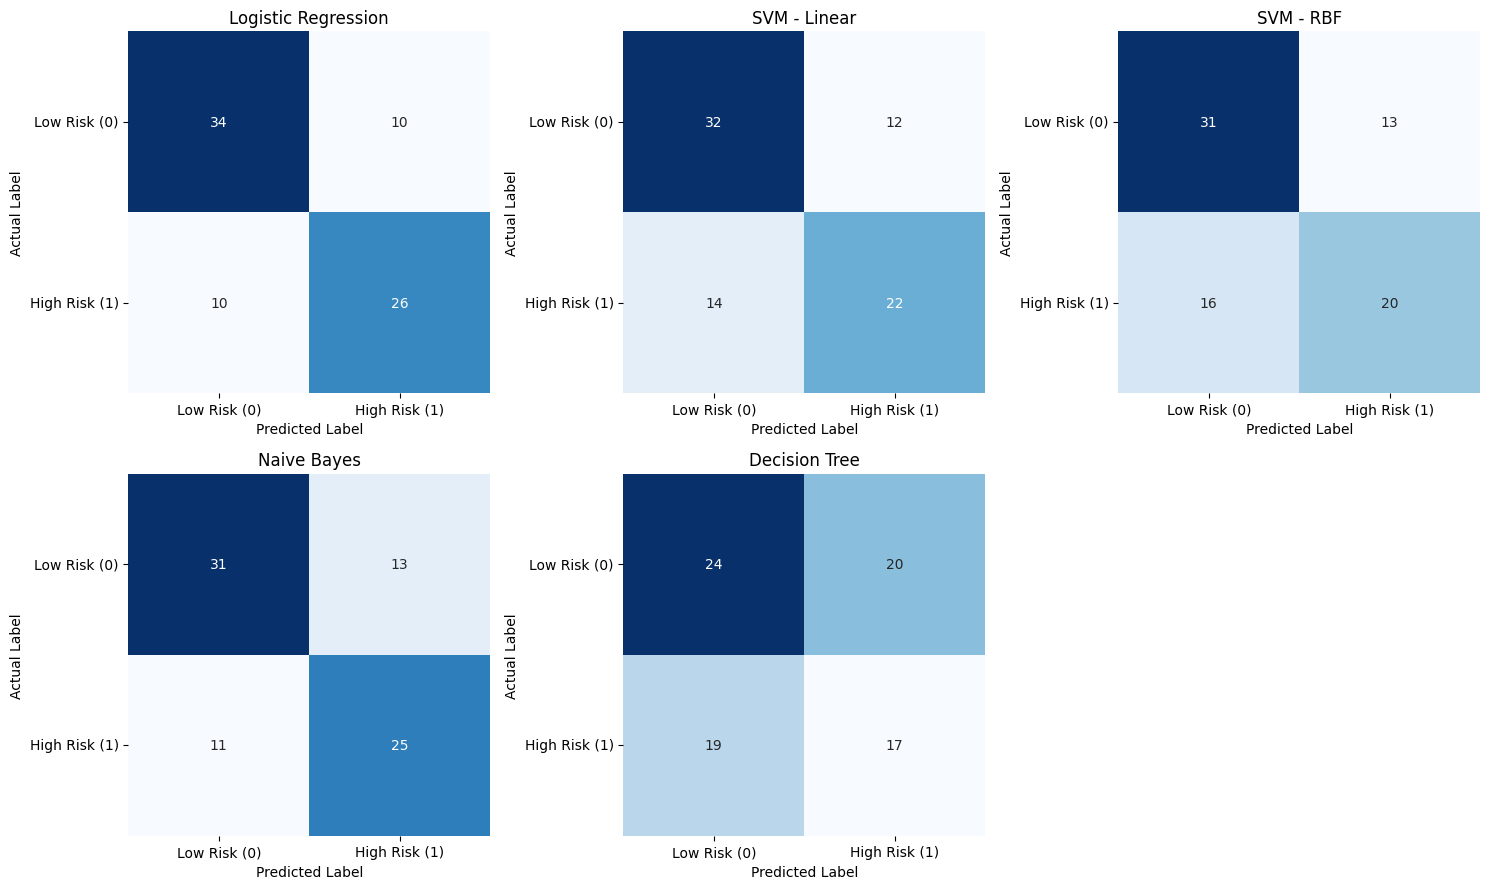

In [79]:
#Confusion Matrices

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

axes = axes.ravel()

for i, (name, model) in enumerate(final_models.items()):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axes[i]
    )

    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("Actual Label")

    axes[i].set_xticklabels(
        ["Low Risk (0)", "High Risk (1)"]
    )

    axes[i].set_yticklabels(
        ["Low Risk (0)", "High Risk (1)"],
        rotation=0
    )

# Hide unused subplot
for j in range(len(final_models), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

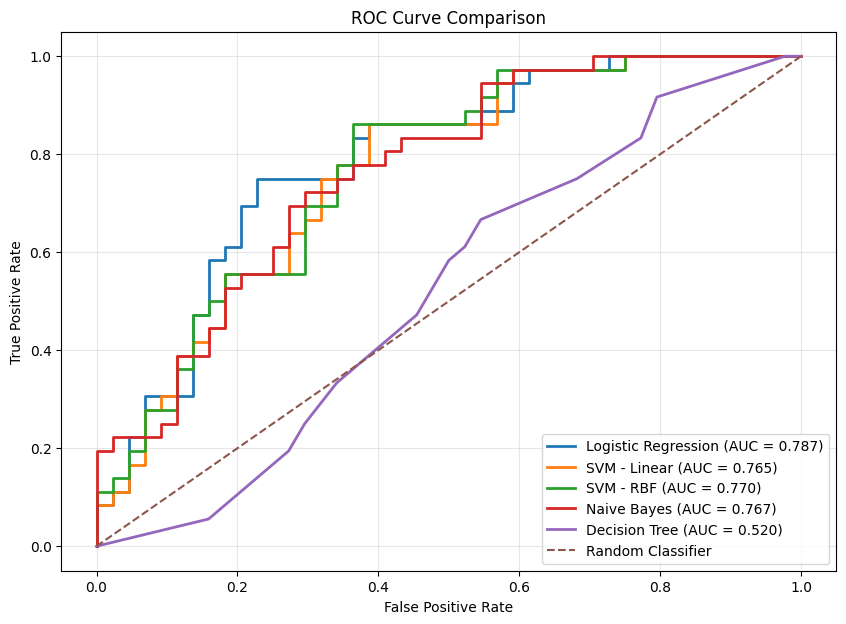

In [80]:
#ROC Curves

plt.figure(figsize=(10, 7))

for name, model in final_models.items():

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_score
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )


# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Part D — Model Evaluation

The final tuned models were evaluated on the held-out test set using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, and ROC curves.

Accuracy measures the proportion of all test observations that were classified correctly. Precision measures the proportion of predicted high-risk cases that were actually high-risk, while recall measures the proportion of actual high-risk cases that were correctly identified. The F1-score provides a balance between precision and recall. ROC-AUC measures the model's ability to distinguish between the two disease-risk classes across different classification thresholds.

The confusion matrices provide additional information about true positives, true negatives, false positives, and false negatives. In this disease-risk problem, particular attention should be paid to the recall for the High Risk (1) class because false negatives represent high-risk observations that were classified as low risk.

The ROC curves provide a visual comparison of the discrimination performance of the models. The final model comparison table reports the test-set results for Logistic Regression, Linear SVM, RBF SVM, Gaussian Naive Bayes, and Decision Tree.

Part E — Analysis & Conclusion

Based on the test-set results from the tuned models in Part D, the comparison is:

Model	Accuracy	Precision	Recall	F1-Score	ROC-AUC
Logistic Regression	0.7500	0.7222	0.7222	0.7222	0.7872
SVM – Linear	0.6750	0.6471	0.6111	0.6286	0.7652
SVM – RBF	0.6375	0.6061	0.5556	0.5797	0.7702
Naive Bayes	0.7000	0.6579	0.6944	0.6757	0.7670
Decision Tree	0.5125	0.4595	0.4722	0.4658	0.5202

These are based on the exact train/test split (80/20, random_state=42, stratified) and the tuning grids used in Part C.

Which model performed best overall? Why?

For this dataset, Logistic Regression performed best overall on the test set.

It achieved:

Accuracy: 75.00%
Precision: 72.22%
Recall: 72.22%
F1-score: 72.22%
ROC-AUC: 0.7872

It also produced a relatively balanced precision and recall, rather than performing well on one metric while performing poorly on another.

Why might Logistic Regression perform well here?

The dataset contains relatively straightforward numerical and binary health-related features such as:

age
BMI
blood pressure
cholesterol
blood sugar
maximum heart rate
smoking
family history
exercise angina

Logistic Regression works well when the relationship between the predictors and the probability of the target class can be reasonably represented by a linear decision boundary.

The results suggest that a relatively simple linear model captured useful patterns in this particular dataset. The relatively strong ROC-AUC also indicates useful discrimination between the two disease-risk classes.

However, this result should not be interpreted as evidence that Logistic Regression would be the best medical model in a real clinical population. The dataset is small and appears to be a machine-learning exercise dataset, so external validation would be necessary before any clinical conclusion.

Which model performed worst? What might explain that?

The Decision Tree had the lowest test-set performance among the models tested:

Accuracy: 51.25%
Precision: 45.95%
Recall: 47.22%
F1-score: 46.58%
ROC-AUC: 52.02%

The tuned tree had:

max_depth = 4
Possible explanation

Decision Trees can be sensitive to the particular training sample and can create overly specific decision rules. Even though we restricted the tree's depth to reduce overfitting, the resulting tree may not have captured the underlying patterns as effectively as the linear models.

Another possibility is that the relationships between the features and disease_risk in this dataset are not well represented by the particular threshold-based splits selected by the tree.

The relatively low ROC-AUC indicates that the tree had limited ability to distinguish the two classes on this test set.

It is also important not to generalize this result to Decision Trees generally. A poor result on this dataset does not mean Decision Trees are inherently unsuitable for medical classification.

For a real medical screening tool, Precision or Recall?

For a screening tool, I would generally prioritize Recall (sensitivity) for the high-risk/disease-positive class.

Why?

Recall answers:

"Of all the patients who actually have the condition, how many did the model identify?"

A false negative occurs when a patient who is actually high-risk is classified as low-risk.

In an initial screening context, missing a potentially high-risk patient can be particularly concerning because that person might not receive further investigation.

For example:

100 actual high-risk patients
        ↓
Model identifies 90
        ↓
Recall = 90%

A higher recall means fewer high-risk cases are missed.

But precision still matters

Optimizing recall alone can result in many false positives.

For example:

More patients flagged as high-risk
              ↓
More follow-up tests
              ↓
Higher healthcare cost
              ↓
Potential patient anxiety

Therefore, a practical screening system would usually seek high sensitivity/recall while maintaining an acceptable level of precision, rather than optimizing one metric in isolation.

For your dataset, notice that Naive Bayes has recall = 69.44%, compared with Logistic Regression's 72.22%. The final choice should therefore consider the intended screening threshold and the relative consequences of false negatives and false positives.

Which Model Should Deploy in Production?

For this particular exercise, Logistic Regression provides the most straightforward production candidate based on the observed test-set results, especially because it combines the highest test accuracy and ROC-AUC in this experiment with relatively balanced precision and recall.

There are three additional considerations:

1. Accuracy and discrimination

Logistic Regression:

Accuracy = 75.00%
ROC-AUC  = 78.72%

These were the strongest values among the tested models.

2. Interpretability

Logistic Regression is relatively easy to explain.

Its coefficients can indicate how individual features are associated with the predicted log-odds of disease risk.

That is useful in a medical context because stakeholders may want to understand why a prediction was produced.

3. Speed

For a dataset with only a small number of features, Logistic Regression is computationally inexpensive for both training and prediction.

Therefore, it is practical for deployment from a computational perspective.

Important medical-production qualification

I would not deploy this model directly as a real medical screening tool based solely on this assignment.

Before clinical use, it would require substantially more validation, including:

A much larger and representative patient population
External validation on data from different patients/sites
Careful assessment of sensitivity and specificity
Calibration of predicted probabilities
Evaluation of false-negative and false-positive consequences
Appropriate clinical review
Monitoring for dataset/population shift
Privacy, safety, and regulatory requirements

So, for the academic dataset, Logistic Regression is the strongest candidate based on the measured results. For a real clinical system, these test-set results alone would not be sufficient to justify deployment.

# Part E — Analysis & Conclusion

Among the models tested, Logistic Regression produced the strongest overall test-set performance. It achieved an accuracy of 75.00%, precision of 72.22%, recall of 72.22%, F1-score of 72.22%, and ROC-AUC of 78.72%. Its balanced precision and recall indicate that it performed reasonably consistently in identifying both disease-risk classes.

The Decision Tree produced the lowest performance, with an accuracy of 51.25%, F1-score of 46.58%, and ROC-AUC of 52.02%. One possible explanation is that the threshold-based splits of the tree did not represent the relationships in this particular dataset as effectively as the other models. Although the tree depth was tuned to reduce overfitting, its performance remained relatively weak on the unseen test set.

For a real medical screening application, Recall (sensitivity) would generally be an important priority because false negatives represent patients with potential disease risk who are not identified by the screening system. However, precision should also be considered because excessive false positives can lead to unnecessary follow-up tests, costs, and patient anxiety. Therefore, a practical screening system should aim for high sensitivity while maintaining an acceptable precision level.

For this academic dataset, Logistic Regression would be the most straightforward production candidate because it achieved the strongest observed test-set results and is relatively interpretable and computationally efficient. However, these results alone would not be sufficient for deployment as a real medical screening system. A real clinical application would require larger datasets, external validation, probability calibration, clinical evaluation, safety assessment, and appropriate regulatory review.